In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# Load data
df = pd.read_csv('creditcard.csv')

print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Fraud cases: {df['Class'].sum()}")
print(f"Legit cases: {(df['Class']==0).sum()}")

Data loaded successfully!
Shape: (284807, 31)
Fraud cases: 492
Legit cases: 284315


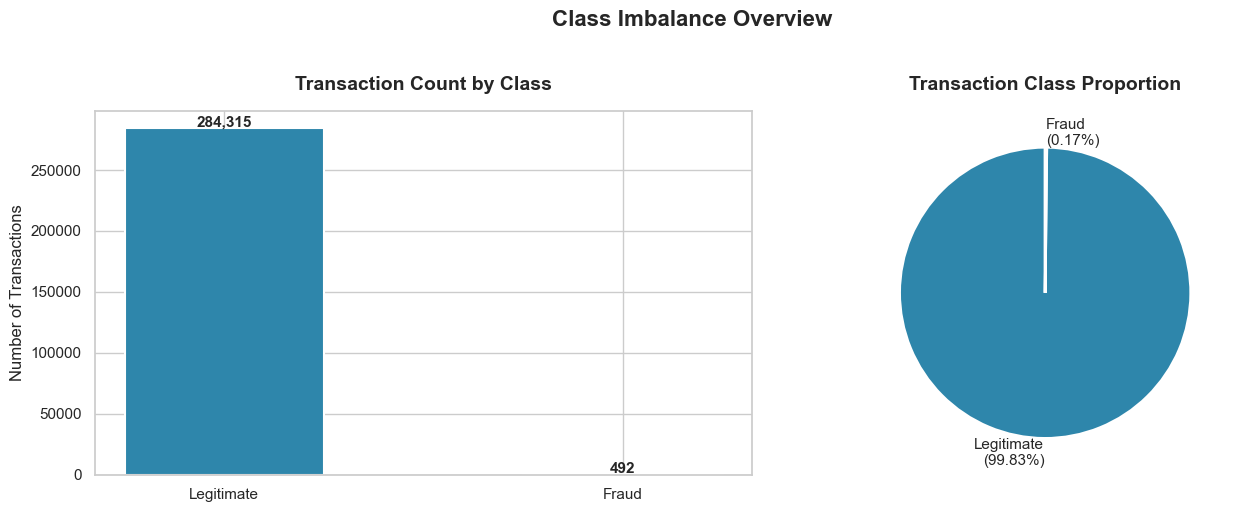

Chart 1 saved!


In [3]:
# Chart 1: Fraud vs Legitimate Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2E86AB', '#E84855']
counts = df['Class'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], counts.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
axes[0].set_title('Transaction Count by Class', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

# Pie chart
axes[1].pie(counts.values, labels=['Legitimate\n(99.83%)', 'Fraud\n(0.17%)'],
            colors=colors, autopct='', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Transaction Class Proportion', fontsize=14, fontweight='bold', pad=15)

plt.suptitle('Class Imbalance Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

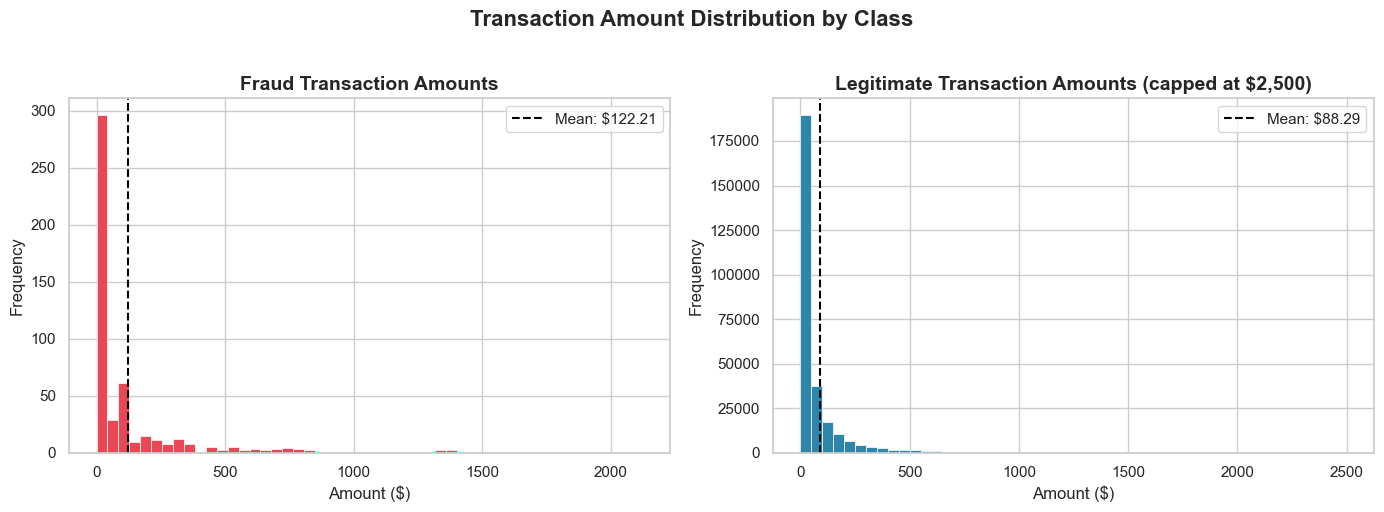

Chart 2 saved!


In [4]:
# Chart 2: Amount Distribution - Fraud vs Legitimate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

# Histogram - Fraud amounts
axes[0].hist(fraud, bins=50, color='#E84855', edgecolor='white', linewidth=0.5)
axes[0].set_title('Fraud Transaction Amounts', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(fraud.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: ${fraud.mean():.2f}')
axes[0].legend()

# Histogram - Legitimate amounts (capped at 2500 for visibility)
legit_capped = legit[legit <= 2500]
axes[1].hist(legit_capped, bins=50, color='#2E86AB', edgecolor='white', linewidth=0.5)
axes[1].set_title('Legitimate Transaction Amounts (capped at $2,500)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(legit.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: ${legit.mean():.2f}')
axes[1].legend()

plt.suptitle('Transaction Amount Distribution by Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart2_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

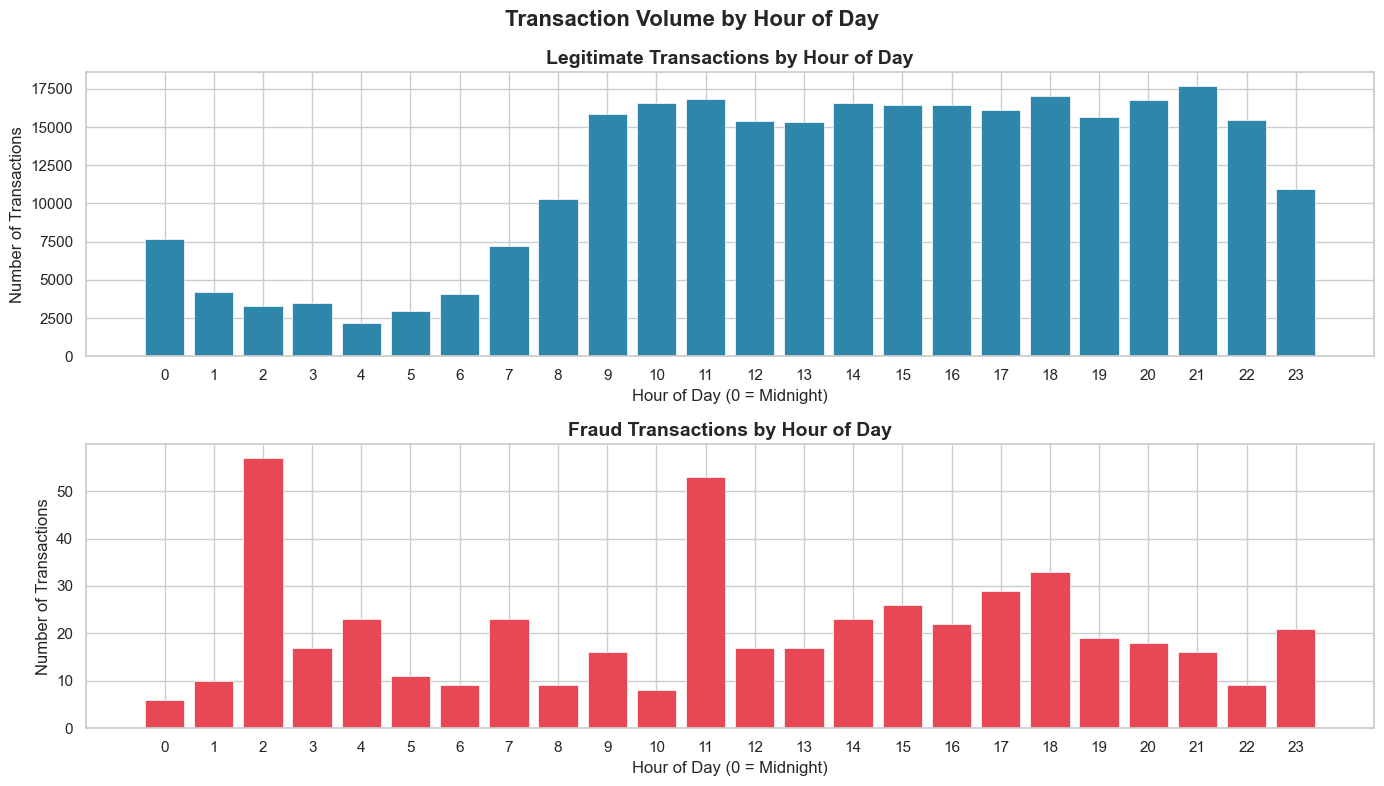

Chart 3 saved!


In [5]:
# Chart 3: Transaction Volume by Time (Hour of Day)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Convert seconds to hours
df['Hour'] = (df['Time'] / 3600) % 24

fraud_by_hour = df[df['Class']==1].groupby(df['Hour'].astype(int))['Class'].count()
legit_by_hour = df[df['Class']==0].groupby(df['Hour'].astype(int))['Class'].count()

# Legitimate volume by hour
axes[0].bar(legit_by_hour.index, legit_by_hour.values, color='#2E86AB', edgecolor='white', linewidth=0.5)
axes[0].set_title('Legitimate Transactions by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xlabel('Hour of Day (0 = Midnight)')
axes[0].set_xticks(range(0, 24))

# Fraud volume by hour
axes[1].bar(fraud_by_hour.index, fraud_by_hour.values, color='#E84855', edgecolor='white', linewidth=0.5)
axes[1].set_title('Fraud Transactions by Hour of Day', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_xlabel('Hour of Day (0 = Midnight)')
axes[1].set_xticks(range(0, 24))

plt.suptitle('Transaction Volume by Hour of Day', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

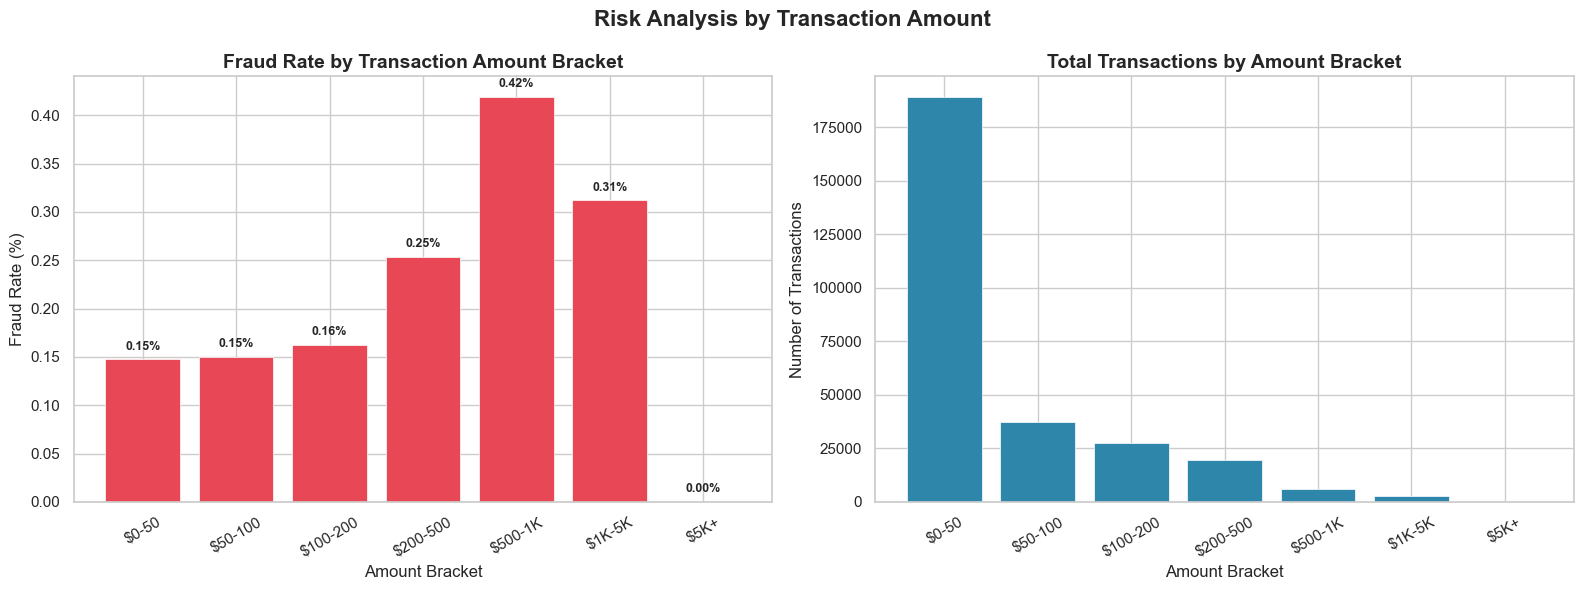

Chart 4 saved!


In [6]:
# Chart 4: Fraud Rate by Amount Bracket
df['Amount_Bracket'] = pd.cut(df['Amount'], 
    bins=[0, 50, 100, 200, 500, 1000, 5000, 30000],
    labels=['$0-50', '$50-100', '$100-200', '$200-500', '$500-1K', '$1K-5K', '$5K+'])

fraud_rate = df.groupby('Amount_Bracket', observed=True).apply(
    lambda x: (x['Class'].sum() / len(x)) * 100).reset_index()
fraud_rate.columns = ['Amount_Bracket', 'Fraud_Rate']

total_counts = df.groupby('Amount_Bracket', observed=True).size().reset_index(name='Count')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fraud rate by bracket
bars = axes[0].bar(fraud_rate['Amount_Bracket'], fraud_rate['Fraud_Rate'], 
                    color='#E84855', edgecolor='white', linewidth=0.5)
axes[0].set_title('Fraud Rate by Transaction Amount Bracket', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Amount Bracket')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, fraud_rate['Fraud_Rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}%', ha='center', fontsize=9, fontweight='bold')

# Transaction count by bracket
axes[1].bar(total_counts['Amount_Bracket'], total_counts['Count'],
            color='#2E86AB', edgecolor='white', linewidth=0.5)
axes[1].set_title('Total Transactions by Amount Bracket', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Amount Bracket')
axes[1].set_ylabel('Number of Transactions')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Risk Analysis by Transaction Amount', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_amount_brackets.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

df = pd.read_csv('creditcard.csv')
df['Hour'] = (df['Time'] / 3600) % 24
df['Amount_Bracket'] = pd.cut(df['Amount'],
    bins=[0, 50, 100, 200, 500, 1000, 5000, 30000],
    labels=['$0-50', '$50-100', '$100-200', '$200-500', '$500-1K', '$1K-5K', '$5K+'])

print("Data reloaded!")

Data reloaded!


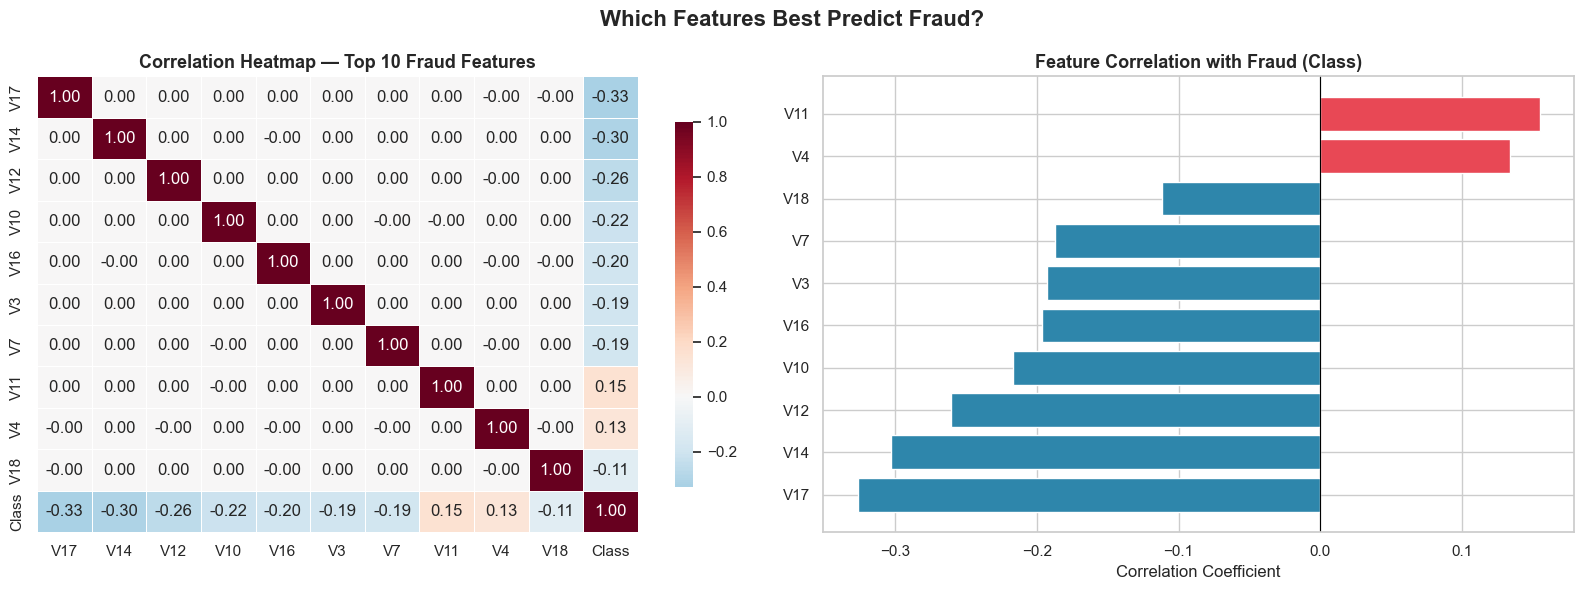

Chart 5 saved!


In [8]:
# Chart 5: Top features correlated with fraud
# Drop non-numeric columns before correlation
df_numeric = df.drop(columns=['Amount_Bracket'])

correlations = df_numeric.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
top_features = correlations.head(10).index.tolist()

corr_matrix = df_numeric[top_features + ['Class']].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Heatmap — Top 10 Fraud Features', fontsize=13, fontweight='bold')

# Bar chart of individual correlations with Class
top_corr = df_numeric[top_features].corrwith(df_numeric['Class']).sort_values()
colors_corr = ['#E84855' if v > 0 else '#2E86AB' for v in top_corr.values]
axes[1].barh(top_corr.index, top_corr.values, color=colors_corr, edgecolor='white')
axes[1].set_title('Feature Correlation with Fraud (Class)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Which Features Best Predict Fraud?', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13124\3423682922.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([legit_vals, fraud_vals],
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13124\3423682922.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([legit_vals, fraud_vals],
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13124\3423682922.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([legit_vals, fraud_vals],
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13124\3423682922.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 't

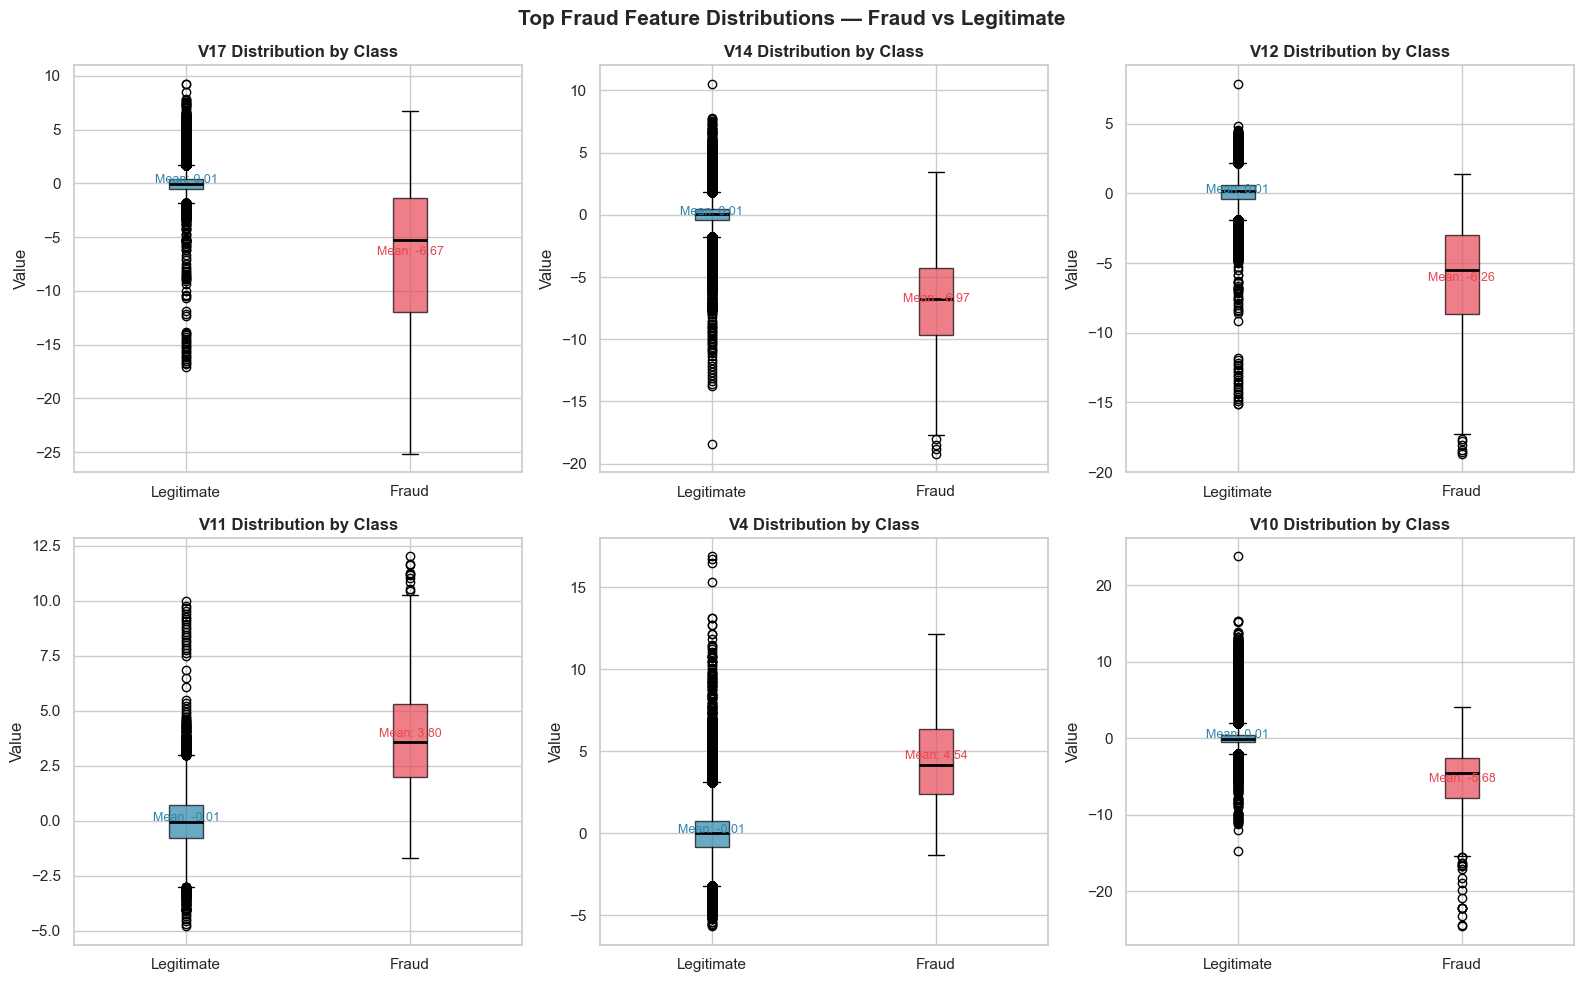

Chart 6 saved!


In [9]:
# Chart 6: Box plots - Fraud vs Legit for top 6 features
top6 = ['V17', 'V14', 'V12', 'V11', 'V4', 'V10']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(top6):
    fraud_vals = df[df['Class']==1][feature]
    legit_vals = df[df['Class']==0][feature]
    
    axes[i].boxplot([legit_vals, fraud_vals],
                    labels=['Legitimate', 'Fraud'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#2E86AB', alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    
    # Color fraud box differently
    boxes = axes[i].patches
    if len(boxes) > 1:
        boxes[1].set_facecolor('#E84855')
        boxes[1].set_alpha(0.7)
    
    axes[i].set_title(f'{feature} Distribution by Class', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Value')
    
    # Add mean annotations
    axes[i].annotate(f'Mean: {legit_vals.mean():.2f}', xy=(1, legit_vals.mean()),
                     fontsize=9, color='#2E86AB', ha='center')
    axes[i].annotate(f'Mean: {fraud_vals.mean():.2f}', xy=(2, fraud_vals.mean()),
                     fontsize=9, color='#E84855', ha='center')

plt.suptitle('Top Fraud Feature Distributions — Fraud vs Legitimate', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved!")

NameError: name 'plt' is not defined

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

df = pd.read_csv('creditcard.csv')
df['Hour'] = (df['Time'] / 3600) % 24
df['Amount_Bracket'] = pd.cut(df['Amount'],
    bins=[0, 50, 100, 200, 500, 1000, 5000, 30000],
    labels=['$0-50', '$50-100', '$100-200', '$200-500', '$500-1K', '$1K-5K', '$5K+'])

print("Data reloaded! Ready for charts.")

Data reloaded! Ready for charts.


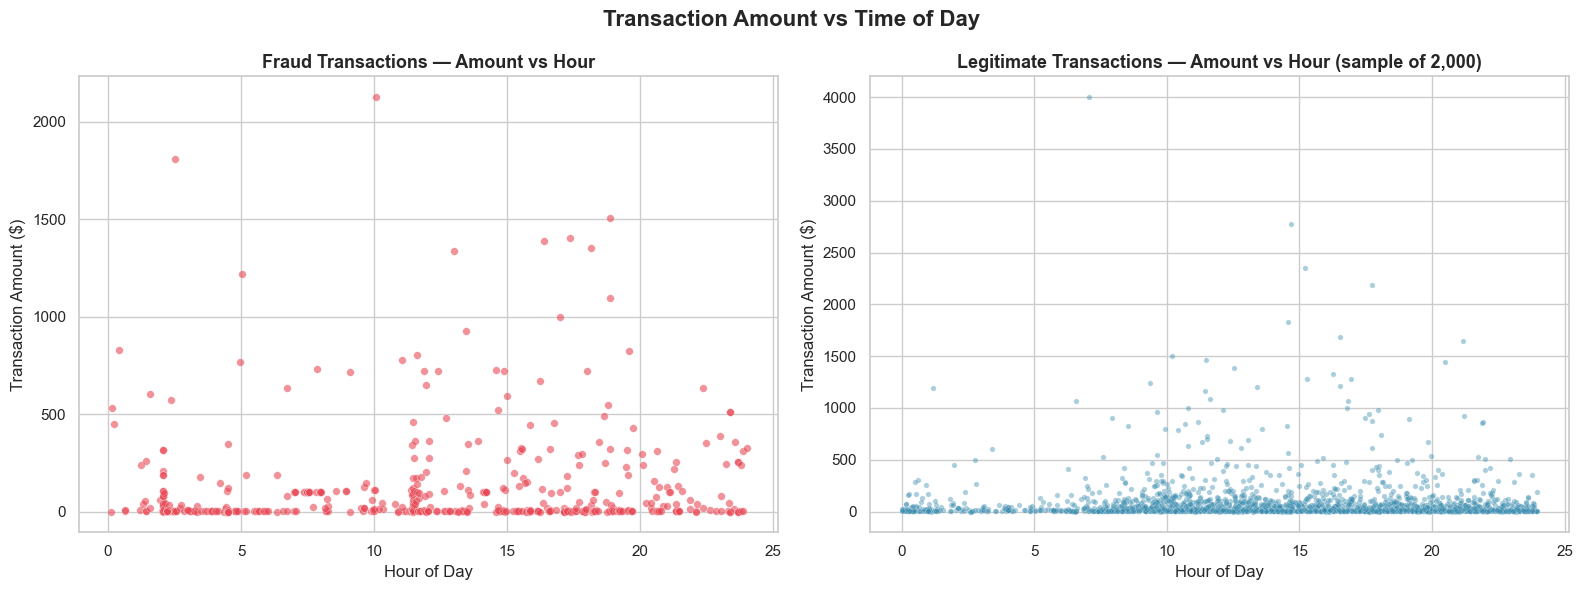

Chart 7 regenerated!


In [2]:
# Chart 7 regeneration
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fraud_df = df[df['Class'] == 1]
legit_sample = df[df['Class'] == 0].sample(2000, random_state=42)

axes[0].scatter(fraud_df['Hour'], fraud_df['Amount'],
                color='#E84855', alpha=0.6, s=30, edgecolors='white', linewidth=0.3)
axes[0].set_title('Fraud Transactions — Amount vs Hour', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Transaction Amount ($)')

axes[1].scatter(legit_sample['Hour'], legit_sample['Amount'],
                color='#2E86AB', alpha=0.4, s=15, edgecolors='white', linewidth=0.3)
axes[1].set_title('Legitimate Transactions — Amount vs Hour (sample of 2,000)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Transaction Amount ($)')

plt.suptitle('Transaction Amount vs Time of Day', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 regenerated!")

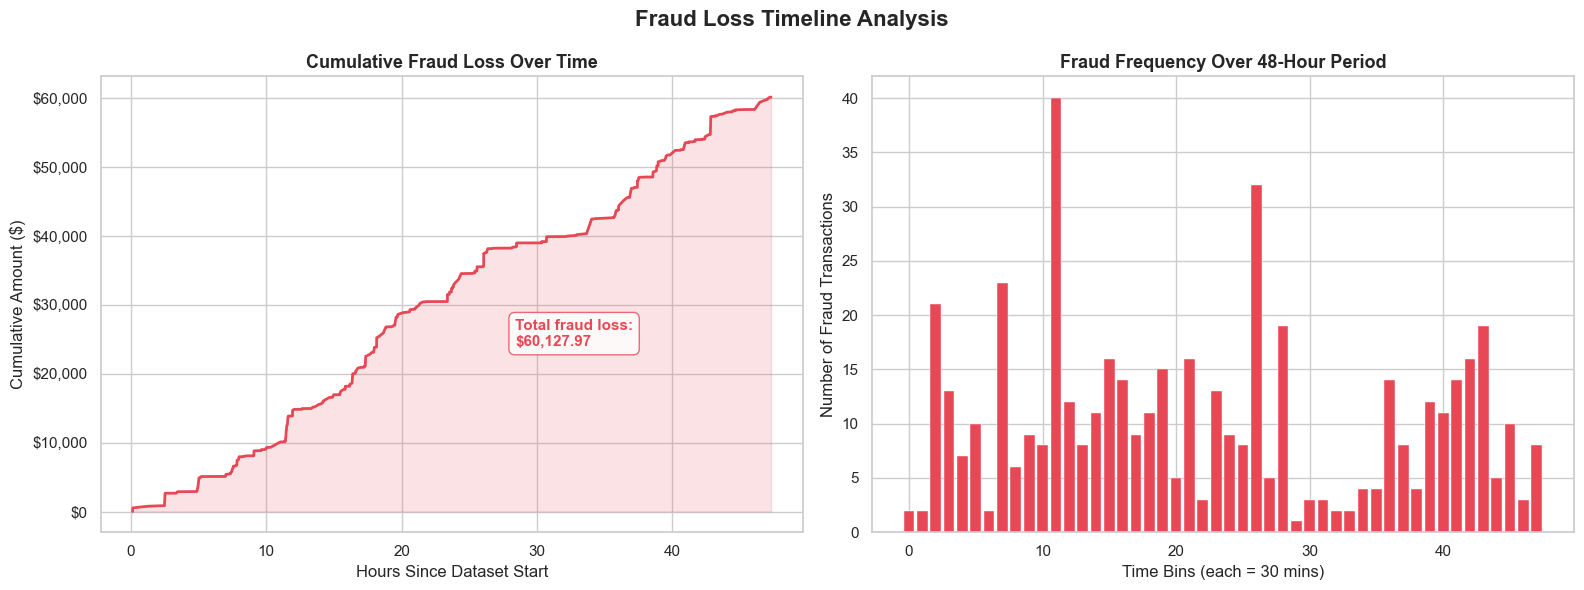

Chart 8 saved!


In [11]:
# Chart 8: Cumulative fraud loss over time
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fraud_df = df[df['Class'] == 1].sort_values('Time')
fraud_df['Cumulative_Loss'] = fraud_df['Amount'].cumsum()
fraud_df['Time_Hours'] = fraud_df['Time'] / 3600

# Cumulative fraud loss
axes[0].plot(fraud_df['Time_Hours'], fraud_df['Cumulative_Loss'],
             color='#E84855', linewidth=2)
axes[0].fill_between(fraud_df['Time_Hours'], fraud_df['Cumulative_Loss'],
                     alpha=0.15, color='#E84855')
axes[0].set_title('Cumulative Fraud Loss Over Time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hours Since Dataset Start')
axes[0].set_ylabel('Cumulative Amount ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Fraud count over time (rolling)
fraud_df['Time_Bin'] = pd.cut(fraud_df['Time_Hours'], bins=48)
fraud_per_bin = fraud_df.groupby('Time_Bin', observed=True).size()
axes[1].bar(range(len(fraud_per_bin)), fraud_per_bin.values,
            color='#E84855', edgecolor='white', linewidth=0.3)
axes[1].set_title('Fraud Frequency Over 48-Hour Period', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Time Bins (each = 30 mins)')
axes[1].set_ylabel('Number of Fraud Transactions')

# Annotations
total_loss = fraud_df['Amount'].sum()
axes[0].annotate(f'Total fraud loss:\n${total_loss:,.2f}',
                 xy=(fraud_df['Time_Hours'].max() * 0.6,
                 fraud_df['Cumulative_Loss'].max() * 0.4),
                 fontsize=11, fontweight='bold', color='#E84855',
                 bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                 edgecolor='#E84855', alpha=0.8))

plt.suptitle('Fraud Loss Timeline Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart8_cumulative_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved!")

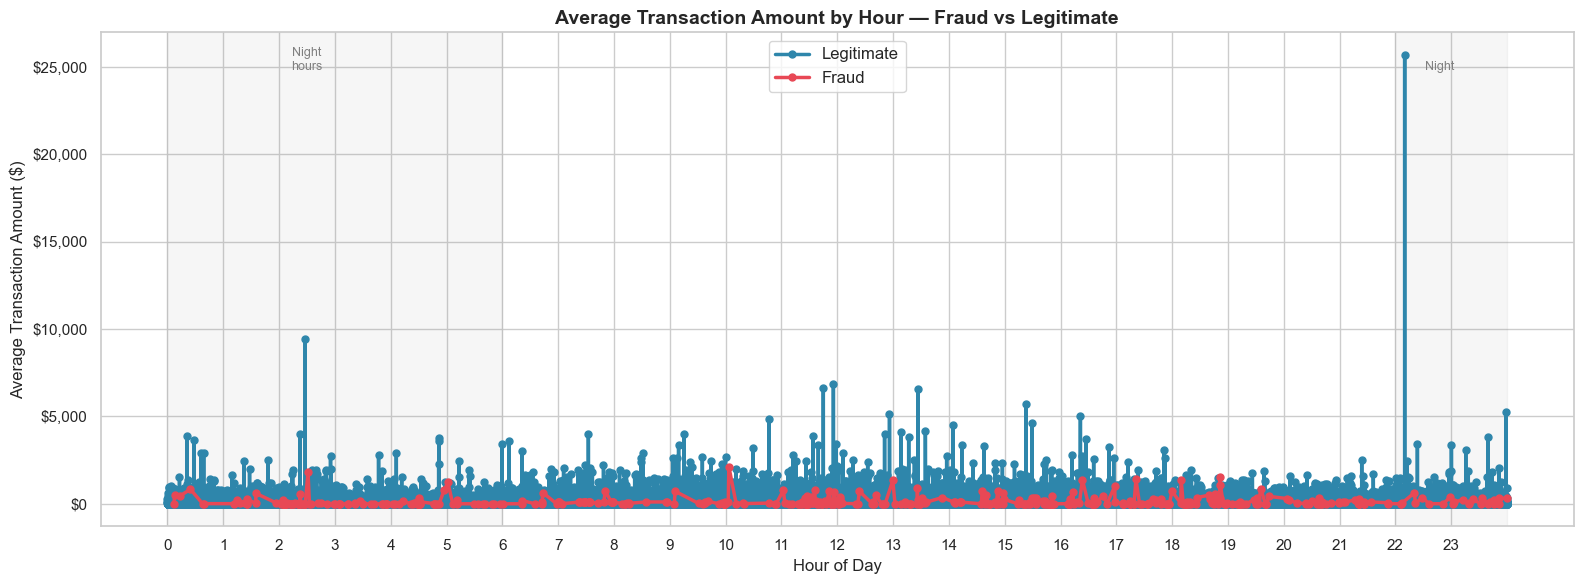

Chart 9 saved!


In [12]:
# Chart 9: Average transaction amount by hour - fraud vs legitimate
hourly = df.groupby(['Hour', 'Class'])['Amount'].mean().reset_index()
fraud_hourly = hourly[hourly['Class']==1]
legit_hourly = hourly[hourly['Class']==0]

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(legit_hourly['Hour'], legit_hourly['Amount'],
        color='#2E86AB', linewidth=2.5, marker='o',
        markersize=5, label='Legitimate')
ax.plot(fraud_hourly['Hour'], fraud_hourly['Amount'],
        color='#E84855', linewidth=2.5, marker='o',
        markersize=5, label='Fraud')

ax.fill_between(legit_hourly['Hour'], legit_hourly['Amount'],
                alpha=0.1, color='#2E86AB')
ax.fill_between(fraud_hourly['Hour'], fraud_hourly['Amount'],
                alpha=0.1, color='#E84855')

ax.set_title('Average Transaction Amount by Hour — Fraud vs Legitimate',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Transaction Amount ($)')
ax.set_xticks(range(0, 24))
ax.legend(fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Highlight night hours
ax.axvspan(0, 6, alpha=0.07, color='gray', label='Night hours')
ax.axvspan(22, 24, alpha=0.07, color='gray')
ax.text(2.5, ax.get_ylim()[1]*0.92, 'Night\nhours',
        ha='center', fontsize=9, color='gray')
ax.text(22.8, ax.get_ylim()[1]*0.92, 'Night',
        ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('chart9_hourly_amounts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 9 saved!")

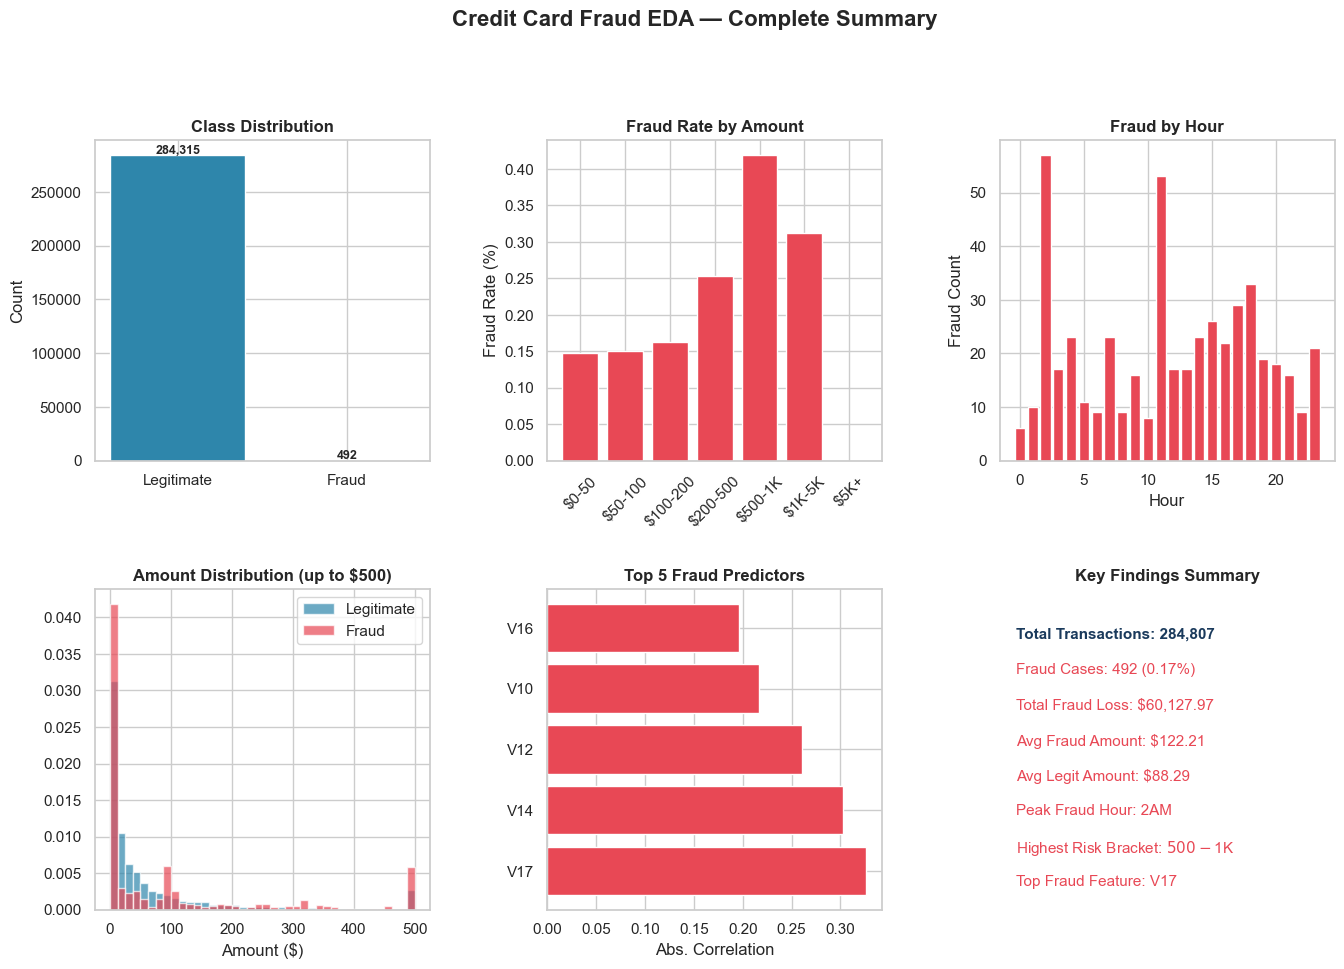

Chart 10 saved! EDA Complete!


In [13]:
# Chart 10: EDA Summary - Key Metrics Dashboard
fig = plt.figure(figsize=(16, 10))

# Define grid
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

# 1. Class distribution
counts = df['Class'].value_counts()
ax1.bar(['Legitimate', 'Fraud'], counts.values, color=['#2E86AB', '#E84855'])
ax1.set_title('Class Distribution', fontweight='bold')
ax1.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax1.text(i, v + 1000, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

# 2. Fraud rate by amount bracket
fraud_rate = df.groupby('Amount_Bracket', observed=True).apply(
    lambda x: (x['Class'].sum() / len(x)) * 100)
ax2.bar(fraud_rate.index, fraud_rate.values, color='#E84855')
ax2.set_title('Fraud Rate by Amount', fontweight='bold')
ax2.set_ylabel('Fraud Rate (%)')
ax2.tick_params(axis='x', rotation=45)

# 3. Hourly fraud count
fraud_by_hour = df[df['Class']==1].groupby(df['Hour'].astype(int)).size()
ax3.bar(fraud_by_hour.index, fraud_by_hour.values, color='#E84855')
ax3.set_title('Fraud by Hour', fontweight='bold')
ax3.set_ylabel('Fraud Count')
ax3.set_xlabel('Hour')

# 4. Amount distribution comparison
ax4.hist(df[df['Class']==0]['Amount'].clip(upper=500),
         bins=40, color='#2E86AB', alpha=0.7, label='Legitimate', density=True)
ax4.hist(df[df['Class']==1]['Amount'].clip(upper=500),
         bins=40, color='#E84855', alpha=0.7, label='Fraud', density=True)
ax4.set_title('Amount Distribution (up to $500)', fontweight='bold')
ax4.set_xlabel('Amount ($)')
ax4.legend()

# 5. Top 5 fraud features
top5_corr = df.drop(columns=['Amount_Bracket']).corr()['Class'].drop('Class').abs().sort_values(ascending=False).head(5)
ax5.barh(top5_corr.index, top5_corr.values, color='#E84855')
ax5.set_title('Top 5 Fraud Predictors', fontweight='bold')
ax5.set_xlabel('Abs. Correlation')

# 6. Key metrics text box
metrics = [
    f"Total Transactions: 284,807",
    f"Fraud Cases: 492 (0.17%)",
    f"Total Fraud Loss: $60,127.97",
    f"Avg Fraud Amount: $122.21",
    f"Avg Legit Amount: $88.29",
    f"Peak Fraud Hour: 2AM",
    f"Highest Risk Bracket: $500-$1K",
    f"Top Fraud Feature: V17",
]
ax6.axis('off')
ax6.set_facecolor('#F8F9FA')
for i, metric in enumerate(metrics):
    ax6.text(0.05, 0.88 - i*0.11, metric, transform=ax6.transAxes,
             fontsize=11, verticalalignment='top',
             color='#E84855' if i > 0 else '#1A3A5C',
             fontweight='bold' if i == 0 else 'normal')
ax6.set_title('Key Findings Summary', fontweight='bold')

fig.suptitle('Credit Card Fraud EDA — Complete Summary', 
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('chart10_eda_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 10 saved! EDA Complete!")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

df = pd.read_csv('creditcard.csv')
df['Hour'] = (df['Time'] / 3600) % 24

print("Data reloaded! Ready to go.")

Data reloaded! Ready to go.


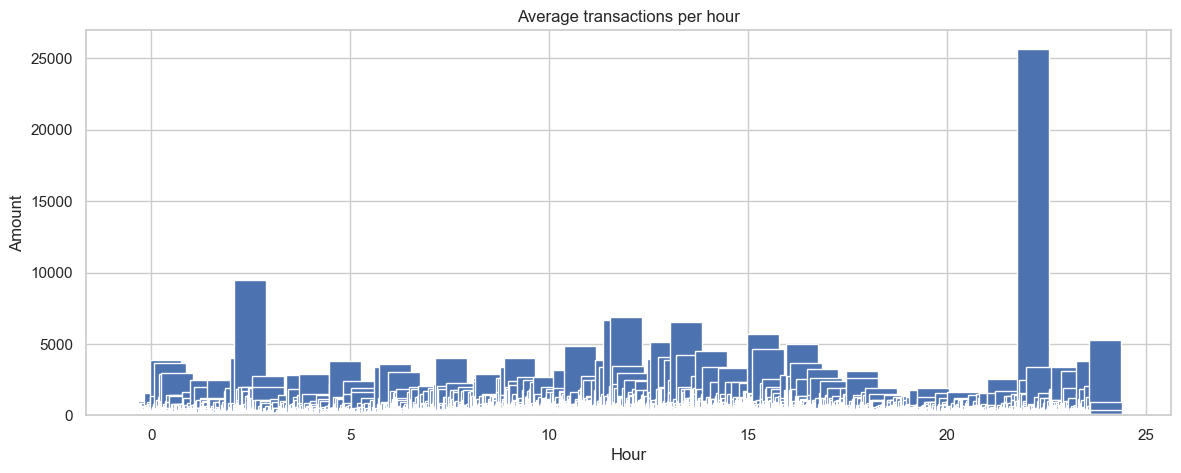

In [5]:
hourly_avg = df.groupby('Hour')['Amount'].mean()
plt.figure(figsize=(14,5))
plt.bar(hourly_avg.index, hourly_avg.values)
plt.title('Average transactions per hour')
plt.xlabel('Hour')
plt.ylabel('Amount')
plt.show()